# Problema de negocio

AndesLink Servicios Digitales S.A. enfrenta un incremento sostenido en la tasa de cancelación voluntaria de clientes (churn), lo cual impacta negativamente en los ingresos recurrentes, el costo de adquisición de nuevos usuarios, la estabilidad del flujo de caja y la eficiencia de las campañas comerciales. En este contexto, resulta necesario anticipar el comportamiento de los clientes para implementar acciones de retención de manera oportuna.

Desde el punto de vista analítico, el problema se aborda mediante el desarrollo de un modelo de Machine Learning que permita predecir la probabilidad de abandono de los clientes a partir de variables relacionadas con su comportamiento, antigüedad, facturación y uso del servicio.

En términos técnicos de Machine Learning, se trata de un problema de clasificación binaria supervisada, donde cada observación corresponde a un cliente y el modelo debe determinar si dicho cliente cancelará o no su suscripción.

## Variable objetivo
La variable objetivo definida es:

`churn`, de tipo binaria:
- churn = 1: el cliente canceló su suscripción
- churn = 0: el cliente continúa activo

El modelo no solo permitirá clasificar a los clientes, sino también estimar la probabilidad de churn, lo que habilita la segmentación por niveles de riesgo y la toma de decisiones basada en umbrales. De este modo, la empresa podrá priorizar acciones de retención sobre aquellos clientes con mayor probabilidad de abandono, optimizando recursos y mejorando la eficiencia de sus estrategias comerciales.

# 1. Importar Librerías y Cargar Data

In [6]:
# Librerias estandar
import math
import os

# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning 
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    f1_score, 
    roc_auc_score
)
from sklearn.model_selection import (
    RandomizedSearchCV, 
    StratifiedKFold, 
    cross_validate, 
    train_test_split
)

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [8]:
base_dir = os.path.dirname(os.getcwd())
path_data = os.path.join(base_dir, "data", "raw", "churn_sintetico.csv")

print(f"Ruta construida: {path_data}")
df_raw = pd.read_csv(path_data)
df = df_raw.copy()
df.head()

Ruta construida: c:\Users\Nico\proyecto_ml\data\raw\churn_sintetico.csv


,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


In [336]:
base_dir = os.path.dirname(os.getcwd())
path_data = os.path.join(base_dir, "data", "raw", "churn_sintetico.csv")

print(f"Ruta construida: {path_data}")
df_raw = pd.read_csv(path_data)
df = df_raw.copy()
df.head()

Ruta construida: c:\Users\Nico\proyecto_ml\data\raw\churn_sintetico.csv


,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


# 2. EDA

In [49]:
print("EXPLORACIÓN INICIAL DE LOS DATOS")
print("=" * 50)

# Dimensionalidad
print(f"→ Dimensionalidad: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
print("─" * 50)

# Tipos de columnas
print("Tipos de columnas:")
display(pd.DataFrame(df.dtypes, columns=['Tipo de dato']).rename_axis('Columna'))
print("─" * 50)



# --- Nulos y duplicados ---
print("→ Comprobación de nulos y duplicados\n")

# Valores nulos
print("- Valores nulos por columna:")
display(pd.DataFrame(df.isnull().sum(), columns=['Cantidad de nulos']).rename_axis('Columna'))

# Filas duplicadas
print("─" * 50)
print(f"- Filas duplicadas en el dataset: {df.duplicated().sum()}")
print("─" * 50)

# Distribución de Churn - Variable objetivo
print("→ Distribución de la variable objetivo 'Churn':")
display(pd.DataFrame(df['churn'].value_counts()))
print("─" * 50)


# Describe
print("\n→ Estadísticas descriptivas:")
display(df.describe())


EXPLORACIÓN INICIAL DE LOS DATOS
→ Dimensionalidad: 5,000 filas × 16 columnas
──────────────────────────────────────────────────
Tipos de columnas:


,Tipo de dato
Columna,
tenure_months,int64
monthly_charge,float64
total_charges,float64
support_tickets,int64
late_payments,int64
avg_monthly_usage_gb,float64
contract_type,str
payment_method,str
internet_service,str


──────────────────────────────────────────────────
→ Comprobación de nulos y duplicados

- Valores nulos por columna:


,Cantidad de nulos
Columna,
tenure_months,0
monthly_charge,0
total_charges,0
support_tickets,0
late_payments,0
avg_monthly_usage_gb,0
contract_type,0
payment_method,0
internet_service,0


──────────────────────────────────────────────────
- Filas duplicadas en el dataset: 0
──────────────────────────────────────────────────
→ Distribución de la variable objetivo 'Churn':


,count
churn,
0,3298
1,1702


──────────────────────────────────────────────────

→ Estadísticas descriptivas:


,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,has_streaming,has_security_pack,num_products,customer_age,is_promo,churn
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,36.407200,65.273282,2371.156582,1.710400,0.69700,120.528458,0.668000,0.539800,2.516400,47.825800,0.386200,0.340400
std,20.839776,17.963425,1555.943231,1.304788,0.84388,49.745297,0.470978,0.498463,1.111746,17.615684,0.486926,0.473891
min,1.000000,15.000000,50.000000,0.000000,0.00000,5.000000,0.000000,0.000000,1.000000,18.000000,0.000000,0.000000
25%,18.000000,53.060000,1100.357500,1.000000,0.00000,86.505000,0.000000,0.000000,2.000000,32.000000,0.000000,0.000000
50%,36.000000,64.965000,2162.810000,2.000000,0.00000,120.030000,1.000000,1.000000,3.000000,48.000000,0.000000,0.000000
75%,55.000000,77.362500,3432.657500,2.000000,1.00000,154.100000,1.000000,1.000000,4.000000,63.000000,1.000000,1.000000
max,72.000000,127.170000,9083.060000,8.000000,5.00000,324.400000,1.000000,1.000000,4.000000,78.000000,1.000000,1.000000


En esta instancia incial, tenemos un primer contacto con el dataset que vamos a trabajar y analizar. Determinamos
+ Dimensionalidad --> 5,000 filas × 16 columnas
+ Tipos datos --> Correctos a simple vista
+ Sin nulos, ni duplicados
+ Variable objetivo desbalanceada, como cabe esperar en análisis de "churn"
+ Estadísticas descriptivas --> habrá que revisar algunas rarezas de las columnas numéricas más adelante. 

Nos centraremos en la variable objetivo `churn` y en buscar qué lo produce

In [50]:
#Variable objetivo
print("- Distribución de la variable objetivo:")
print(f"Churn = {df[df['churn'] == 1].shape[0]}")
print(f"No Churn = {df[df['churn'] == 0].shape[0]}")
print("-"*20)
tasa_churn = df['churn'].mean()
print(f"Tasa de Churn: {tasa_churn:.2%}")

- Distribución de la variable objetivo:
Churn = 1702
No Churn = 3298
--------------------
Tasa de Churn: 34.04%


## 2.1. Análisis de Variables Categóricas


In [51]:
#ver relacion de churn con variables categoricas
cols_cat = df.select_dtypes(exclude='number').columns

data = []

for col in cols_cat:
    tabla = (df.groupby(col)['churn'].mean().sort_values(ascending=False).reset_index().rename(columns={'churn': 'churn_rate'}))

    print(f"\n{col.upper()}")
    display(tabla.style.format({'churn_rate': '{:.2%}'}).background_gradient(subset='churn_rate', cmap='Reds'))


CONTRACT_TYPE


,contract_type,churn_rate
0,mensual,47.53%
1,anual,21.12%
2,bianual,11.56%



PAYMENT_METHOD


,payment_method,churn_rate
0,efectivo,40.54%
1,debito,34.32%
2,transferencia,32.73%
3,credito,32.03%



INTERNET_SERVICE


,internet_service,churn_rate
0,movil,50.90%
1,cable,34.79%
2,ninguno,28.78%
3,fibra,26.83%



REGION


,region,churn_rate
0,centro,34.49%
1,sur,34.05%
2,oeste,33.86%
3,norte,33.48%


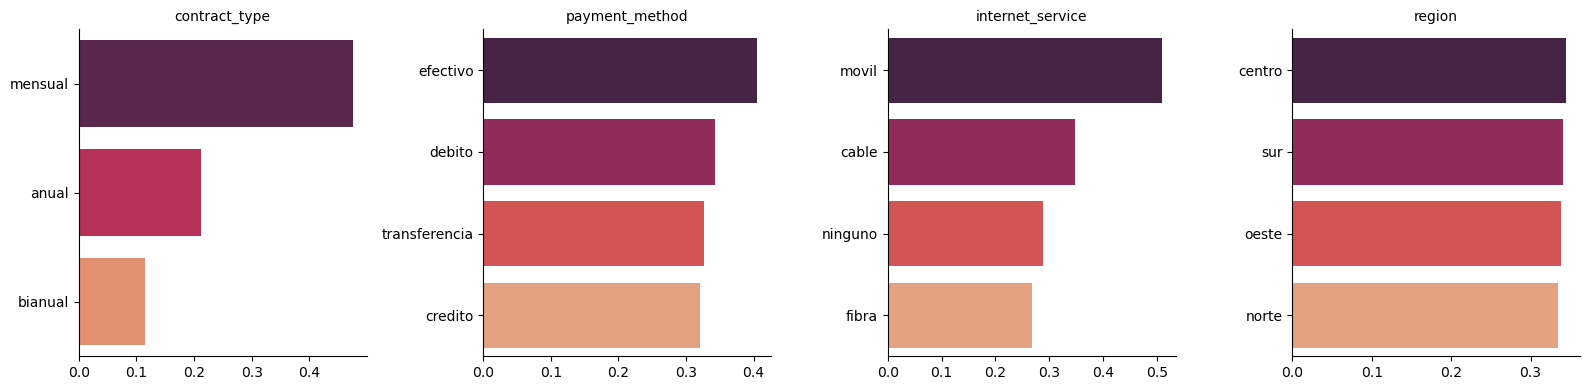

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt


# Configuramos una cuadrícula automática basada en el número de columnas
g = sns.FacetGrid(df.melt(id_vars='churn', value_vars=cols_cat), 
                  col='variable', col_wrap=4, sharex=False, sharey=False, height=4)

# Función para procesar y graficar cada categoría
def plot_churn(data, **kwargs):
    top8 = data.groupby('value')['churn'].mean().sort_values(ascending=False).head(8).reset_index()
    sns.barplot(data=top8, x='churn', y='value', hue='value', palette='rocket', legend=False)

g.map_dataframe(plot_churn)
g.set_titles("{col_name}").set_axis_labels("", "")
plt.tight_layout()
plt.show()

Vemos que no hay casi diferencia entre las categorías de la variable `region`, lo que indica que la ubicación no es un factor determinante. Por el contrario, variables como `contract_type`, `payment_method` e `internet_service` muestran una alta incidencia en el churn, destacando que se dispara en contratos mensuales, servicios de internet móvil y pagos en efectivo.

## 2.2. Análisis de variables numéricas

In [53]:
df_num = df.select_dtypes(include=[np.number])
print("\n→ Estadísticas descriptivas de variables numéricas:")
display(df_num.describe().T)


→ Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
tenure_months,5000.0,36.407200,20.839776,1.0,18.0000,36.000,55.0000,72.00
monthly_charge,5000.0,65.273282,17.963425,15.0,53.0600,64.965,77.3625,127.17
total_charges,5000.0,2371.156582,1555.943231,50.0,1100.3575,2162.810,3432.6575,9083.06
support_tickets,5000.0,1.710400,1.304788,0.0,1.0000,2.000,2.0000,8.00
late_payments,5000.0,0.697000,0.843880,0.0,0.0000,0.000,1.0000,5.00
avg_monthly_usage_gb,5000.0,120.528458,49.745297,5.0,86.5050,120.030,154.1000,324.40
has_streaming,5000.0,0.668000,0.470978,0.0,0.0000,1.000,1.0000,1.00
has_security_pack,5000.0,0.539800,0.498463,0.0,0.0000,1.000,1.0000,1.00
num_products,5000.0,2.516400,1.111746,1.0,2.0000,3.000,4.0000,4.00
customer_age,5000.0,47.825800,17.615684,18.0,32.0000,48.000,63.0000,78.00


Text(0.5, 1.0, 'Matriz de Correlación')

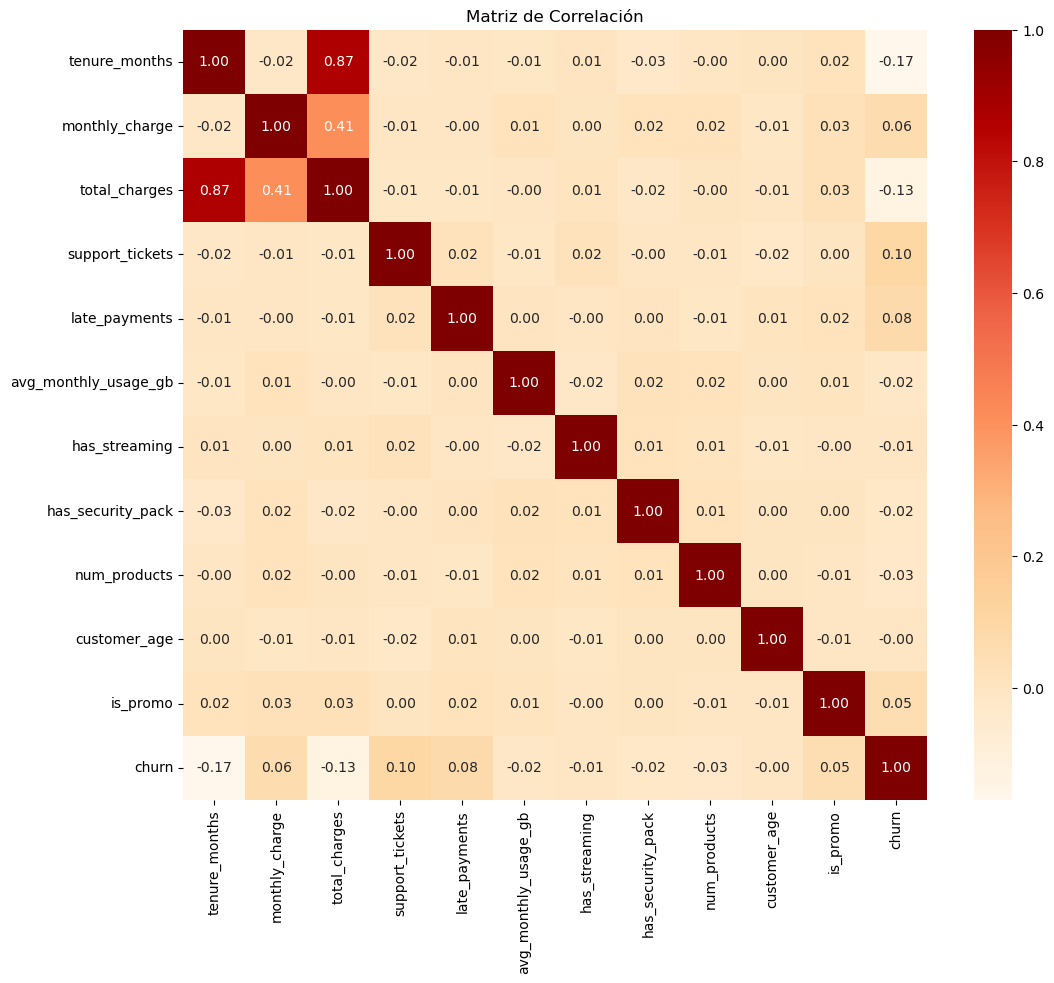

In [54]:
corr = df_num.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='OrRd', cbar=True)
plt.title("Matriz de Correlación")

Se observa una fuerte correlación entre `tenure_months` y `total_charges` (0.87), lo que indica redundancia de información. Respecto al `churn`, la antigüedad (`tenure_months`) es el principal factor de retención (-0.17), mientras que los tickets de soporte (`support_tickets`) son el mayor indicador de fuga (0.10). El resto de las variables no presentan una relación lineal relevante con el abandono.

<Axes: >

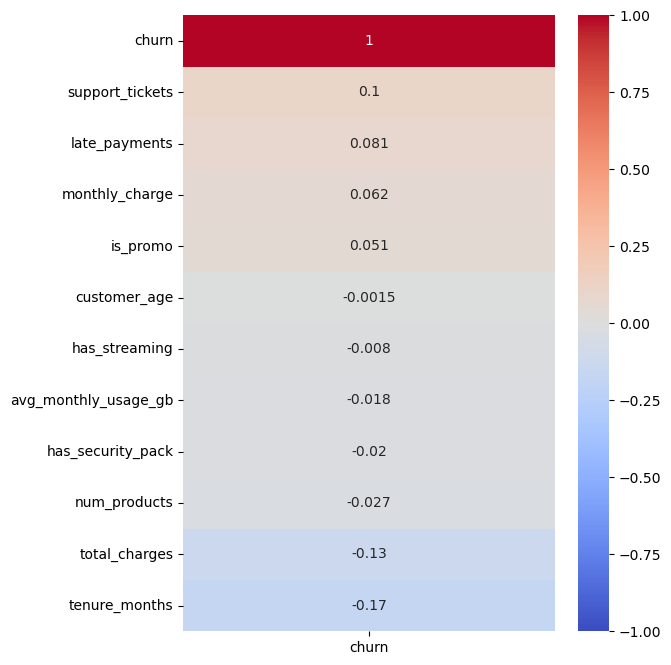

In [55]:
# Correlación con churn

plt.figure(figsize=(6,8))
sns.heatmap(
    corr[["churn"]].sort_values(by="churn", ascending=False),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

Me gustaría ver ahora relaciones no lineales que puedan establecerse con respecto al churn. Para capturar estos patrones no lineales y de interacción entre variables, utilizaremos XGBoost. Este modelo es ideal para nuestro caso ya que detecta umbrales críticos donde el riesgo se dispara, evalúa combinaciones complejas de variables y gestiona la multicolinealidad un poco mejor

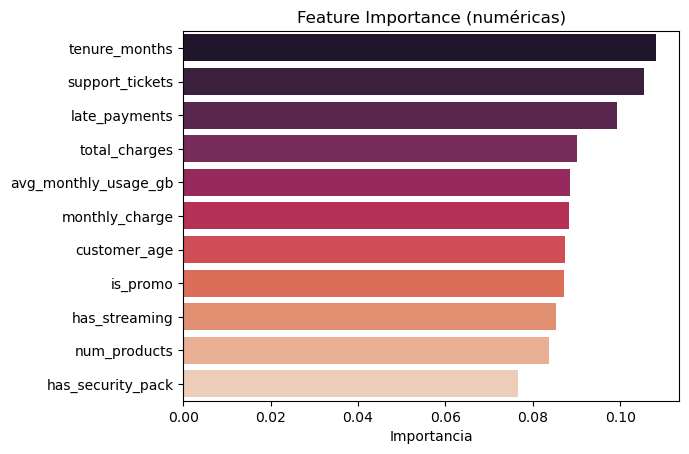

In [56]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# solo numéricas
X = df.select_dtypes(include='number').drop(columns='churn')
y = df['churn']

# modelo
model = XGBClassifier(random_state=42)
model.fit(X, y)

# importance
imp = pd.Series(model.feature_importances_, index=X.columns)\
        .sort_values(ascending=False)

# gráfico
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, palette='rocket', legend=False)
plt.title("Feature Importance (numéricas)")
plt.xlabel("Importancia")
plt.ylabel("")
plt.show()

El modelo ratifica a `tenure_months` como el predictor principal, pero destaca que `support_tickets` y `late_payments` tienen un impacto mucho más profundo de lo que indicaba la correlación lineal. Al mitigar la redundancia con `total_charges`, XGBoost revela que las alertas de insatisfacción y el comportamiento de pago son los disparadores críticos del abandono, capturando patrones no lineales que el análisis previo no lograba dimensionar.

## 2.3. Comprobación visual Outliers (Tukey)

<Axes: >

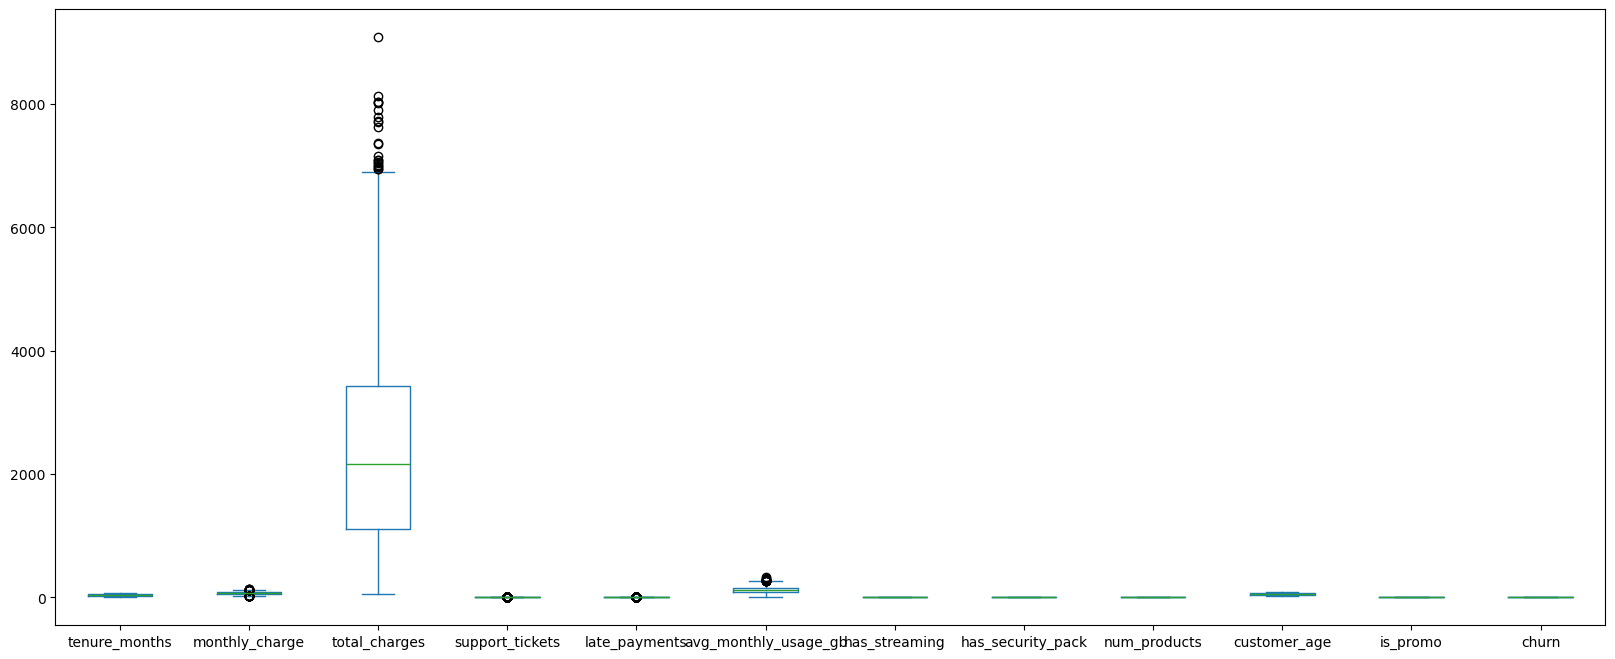

In [57]:
#df_num = df.select_dtypes("number")
df_num.plot(kind="box", figsize=(20, 8))

In [58]:
df_num[['monthly_charge', 'total_charges', 'support_tickets', 'late_payments', 'avg_monthly_usage_gb' ]].describe()

,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,65.273282,2371.156582,1.710400,0.69700,120.528458
std,17.963425,1555.943231,1.304788,0.84388,49.745297
min,15.000000,50.000000,0.000000,0.00000,5.000000
25%,53.060000,1100.357500,1.000000,0.00000,86.505000
50%,64.965000,2162.810000,2.000000,0.00000,120.030000
75%,77.362500,3432.657500,2.000000,1.00000,154.100000
max,127.170000,9083.060000,8.000000,5.00000,324.400000


Es necesario analizar `total_charges` por su gran asimetría

# 3. Feature Insights


## Análisis variable "total_charges"

In [59]:
df['total_charges'].describe()

count    5000.000000
mean     2371.156582
std      1555.943231
min        50.000000
25%      1100.357500
50%      2162.810000
75%      3432.657500
max      9083.060000
Name: total_charges, dtype: float64

<Axes: >

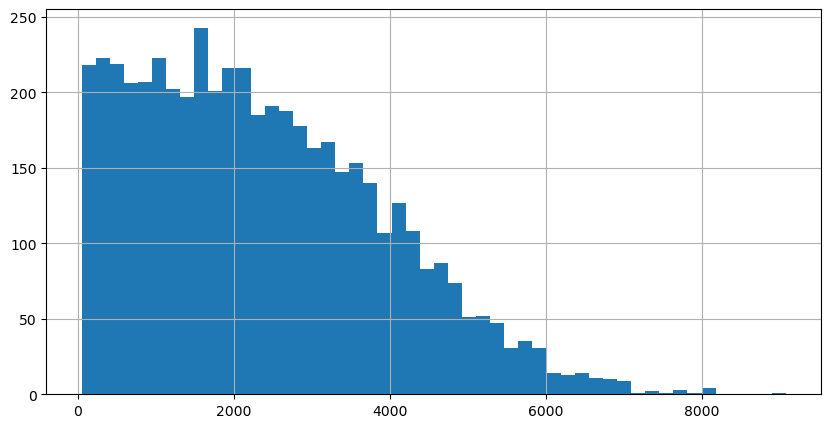

In [60]:
df['total_charges'].hist(bins=50, figsize=(10, 5))

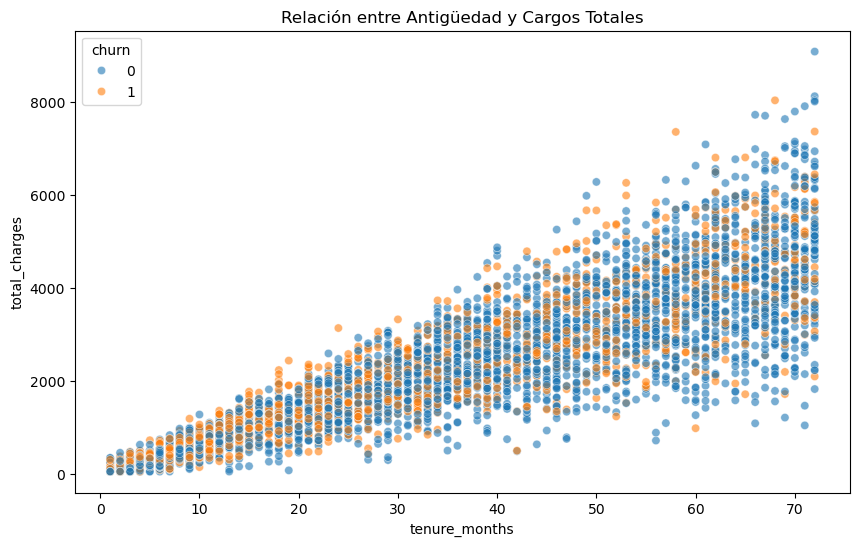

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure_months', y='total_charges', hue='churn', alpha=0.6)
plt.title('Relación entre Antigüedad y Cargos Totales')
plt.show()

La relación es muy lineal, total_charges es casi una "copia" de tenure_months. Lo que tiene sentido dado que a mayor cantidad de meses en la empresa, mayor cantidad de cargas totales. 

C:\Users\Nico\AppData\Local\Temp\ipykernel_17780\501563891.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='total_charges', palette='Set2')


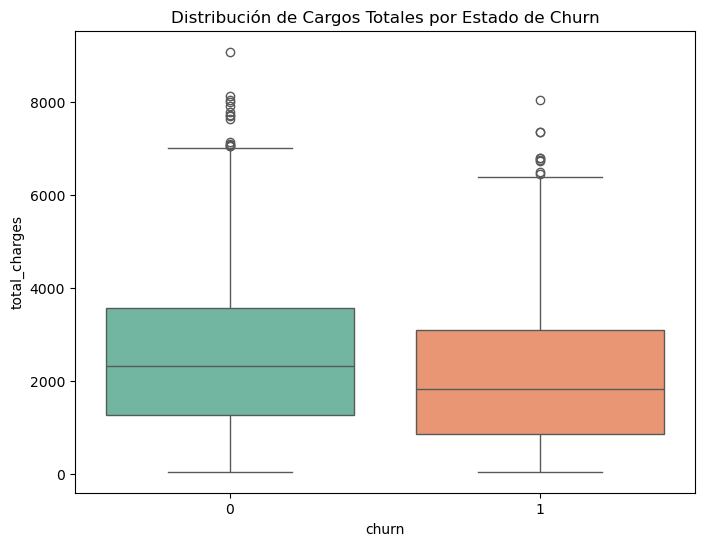

In [62]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='churn', y='total_charges', palette='Set2')
plt.title('Distribución de Cargos Totales por Estado de Churn')
plt.show()

muy parecidos, pero churn 0 tiene valores más altos (clientes Altos o VIP)

Dado que la variable total_charges presenta una asimetría extrema, con valores que triplican el promedio general, optamos por transformarla en categorías (Bajo, Medio, Alto, VIP).

Esta decisión se tomó para evitar que los valores excesivamente altos distorsionen el modelo y afecten la precisión de los resultados. Al pasar los datos a categorías, eliminamos el ruido de los valores atípicos pero conservamos la información clave sobre el nivel de consumo de cada cliente.

In [63]:
# Definimos los cortes exactos de tus cuartiles
q1 = df['total_charges'].quantile(0.25)
q2 = df['total_charges'].quantile(0.50)
q3 = df['total_charges'].quantile(0.75)

# Función de segmentación
def segmentar_total_charges(x):
    if x <= q1: return 'Bajo'
    if x <= q2: return 'Medio-Bajo'
    if x <= q3: return 'Medio-Alto'
    return 'Alto/VIP'

# Aplicar al dataframe
df['total_charges_cat'] = df['total_charges'].apply(segmentar_total_charges)
orden = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto/VIP']

C:\Users\Nico\AppData\Local\Temp\ipykernel_17780\2700745714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='total_charges_cat', y='churn', order=orden, palette='coolwarm')


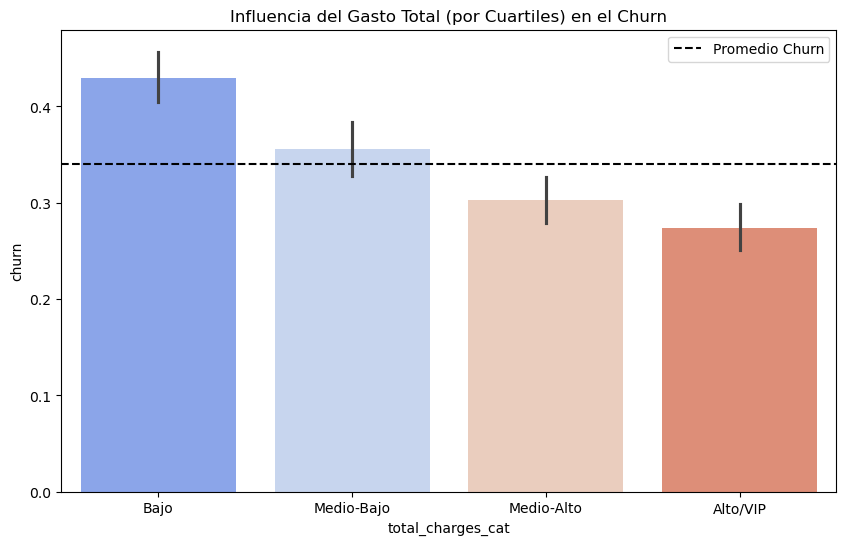

In [64]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='total_charges_cat', y='churn', order=orden, palette='coolwarm')

plt.title('Influencia del Gasto Total (por Cuartiles) en el Churn')
plt.axhline(df['churn'].mean(), color='black', linestyle='--', label='Promedio Churn')
plt.legend()
plt.show()

Muy bueno! A mayor gasto total acumulado, menor es la tasa de churn.

Nota: Eliminar total_charges del dataset

## Análisis variable "support_tickets"

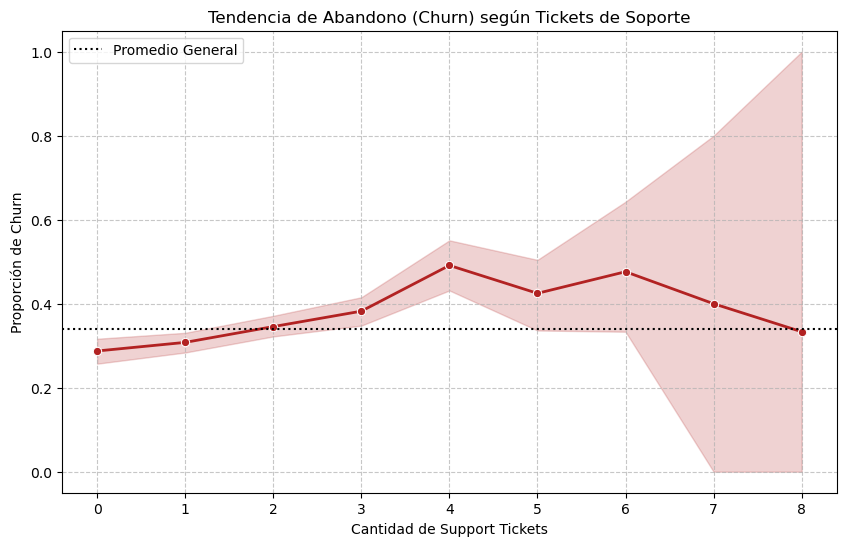

In [65]:
plt.figure(figsize=(10, 6))

# Graficamos la tendencia de Churn según la cantidad de tickets
sns.lineplot(data=df, x='support_tickets', y='churn', marker='o', color='firebrick', linewidth=2)

plt.title('Tendencia de Abandono (Churn) según Tickets de Soporte')
plt.xlabel('Cantidad de Support Tickets')
plt.ylabel('Proporción de Churn')
plt.grid(True, linestyle='--', alpha=0.7)

# Añadimos la línea del promedio general para comparar
plt.axhline(df['churn'].mean(), color='black', linestyle=':', label='Promedio General')
plt.legend()

plt.show()

In [66]:
df['support_tickets'].value_counts()

support_tickets
1    1536
2    1366
0     894
3     756
4     285
5     113
6      42
7       5
8       3
Name: count, dtype: int64

In [67]:
# Creamos una copia para no perder la original por ahora
df['tickets_grouped'] = df['support_tickets'].copy()

# Agrupamos todo lo que sea 5 o más
df.loc[df['tickets_grouped'] >= 5, 'tickets_grouped'] = 5

# Verificamos la nueva distribución
print(df['tickets_grouped'].value_counts().sort_index())

tickets_grouped
0     894
1    1536
2    1366
3     756
4     285
5     163
Name: count, dtype: int64


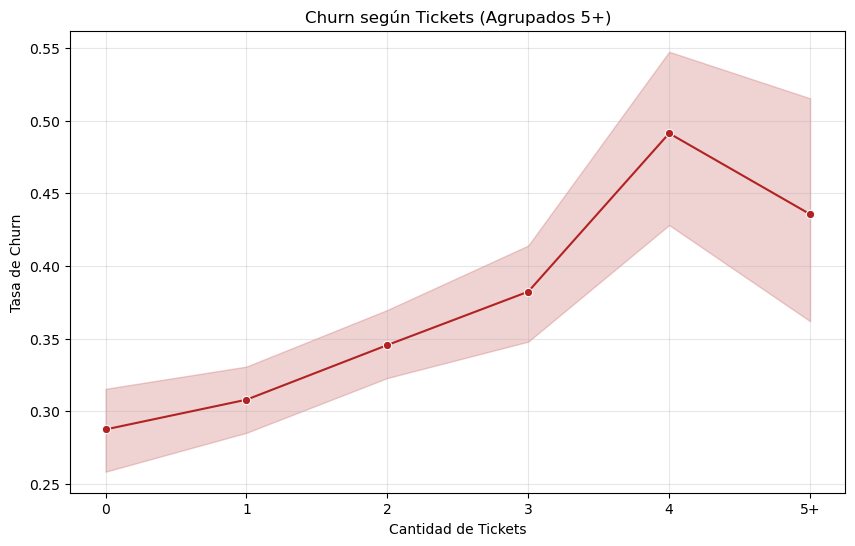

In [68]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='tickets_grouped', y='churn', marker='o', color='firebrick')

plt.title('Churn según Tickets (Agrupados 5+)')
plt.xticks(range(6), ['0', '1', '2', '3', '4', '5+'])
plt.xlabel('Cantidad de Tickets')
plt.ylabel('Tasa de Churn')
plt.grid(True, alpha=0.3)
plt.show()

Se identificó un umbral crítico de deserción al alcanzar los 4 tickets de soporte, donde la tasa de abandono se duplica respecto a los clientes sin incidencias. 

Insight: implementar un protocolo de fidelización proactiva a partir del tercer ticket para mitigar este comportamiento.

Nota: Eliminar support_tickets del dataset

# 4. Feature engineering

In [ ]:
# Riesgo contrato --> captura vulnerabilidad potencial en clientes con contrato mensual y baja antigüedad. (Clientes no atados)

contract_dummies = pd.get_dummies(df['contract_type'], prefix='contract_type')
df['riesgo_contrato'] = contract_dummies['contract_type_mensual'] / (df['tenure_months'] + 1)

In [70]:
# num_servicios --> Cantidad de servicios contratados

cols_servicios = [col for col in df.columns if col.startswith('has_')]

df['num_servicios'] = df[cols_servicios].sum(axis=1)

In [71]:
# cliente_problematico --> combina morosidad y tickets para identificar clientes con potencial riesgo de abandono (incidencia en churn)

if 'late_payments' in df.columns and 'tickets_grouped' in df.columns:
    df['cliente_problematico'] = (
        (df['late_payments'] + df['tickets_grouped']) > 0
    ).astype(int)

In [72]:
# anchor_score --> medida de compromiso del cliente basada en antigüedad y cantidad de productos

df["anchor_score"] = df["tenure_months"] * df["num_products"]

---

In [73]:
# drop variables que modificamos en el Feature Insights--> categorizadas/agrupadas
df.drop(columns=['total_charges', 'support_tickets'], inplace=True)

print(df.columns)

Index(['tenure_months', 'monthly_charge', 'late_payments',
       'avg_monthly_usage_gb', 'contract_type', 'payment_method',
       'internet_service', 'has_streaming', 'has_security_pack',
       'num_products', 'region', 'customer_age', 'is_promo', 'churn',
       'total_charges_cat', 'tickets_grouped', 'riesgo_contrato',
       'num_servicios', 'cliente_problematico', 'anchor_score'],
      dtype='str')


---

# 5. Data Preprocessing


In [74]:
# --- A. Ordinal Encoding (Jerarquía de gasto acumulado) ---
orden_gasto = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto/VIP']

encoder_ord = OrdinalEncoder(categories=[orden_gasto])

df['total_charges_cat'] = encoder_ord.fit_transform(df[['total_charges_cat']])

In [75]:
# 1. Primero separamos X e y
X = df.drop(columns=['churn']) 
y = df['churn']

# 2. Hacemos el split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)



In [76]:
num_cols = [
    'tenure_months',
    'monthly_charge',
    'avg_monthly_usage_gb',
    'customer_age',
    'num_products',
    'tickets_grouped',
    'riesgo_contrato',
    'late_payments',
    'anchor_score'
]

In [77]:
# --- B. One-Hot Encoding (Variables sin orden jerárquico) ---

nominales = ['contract_type', 'payment_method', 'internet_service', 'region']
X_train = pd.get_dummies(X_train, columns=nominales, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominales, drop_first=True)

In [78]:
# 4. Inicializamos el scaler
scaler = StandardScaler()

# 5. AJUSTAMOS Y TRANSFORMAMOS el Train
# Aquí el scaler aprende la media y desviación SOLO de los datos de entrenamiento
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# 6. SOLO TRANSFORMAMOS el Test
# Usamos la info que aprendió del Train (no calculamos nada nuevo del Test)
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 6. Modelos

## 6.1. Modelo Baseline

c:\Users\Nico\anaconda3\envs\proyecto_ml\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:49:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Nico\AppData\Local\Temp\ipykernel_17780\4141235566.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ROC-AUC', y='Model', data=df_baseline, palette='viridis')



--- Tabla de Comparación de Baseline ---
                 Model  Accuracy  F1-Score   ROC-AUC
0  Logistic Regression     0.752  0.566434  0.797990
1        Random Forest     0.726  0.510714  0.765018
2              XGBoost     0.705  0.517185  0.728240


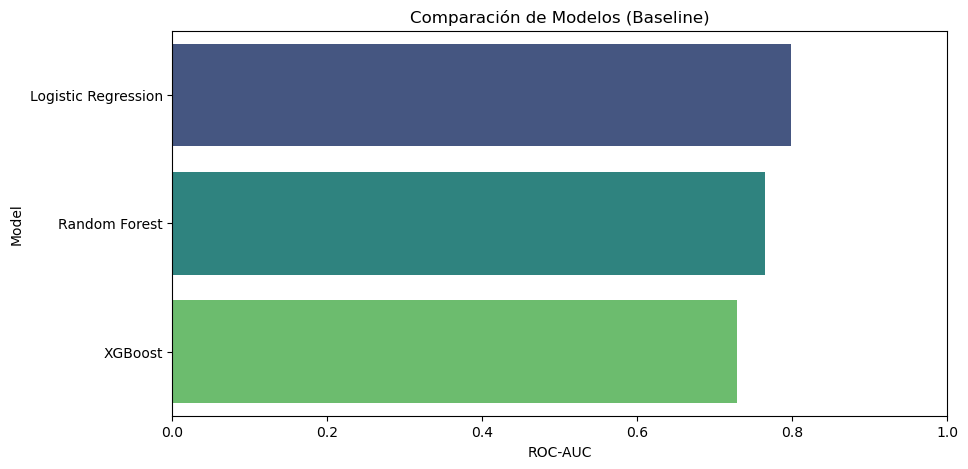

In [79]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 4. Entrenamiento y recolección de métricas
results_list = []

for name, model in models.items():
    # Usamos los datos escalados para todos por consistencia
    model.fit(X_train, y_train)
    
    # Predicciones
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    # Guardar métricas
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

# 5. Visualización de resultados
df_baseline = pd.DataFrame(results_list).sort_values(by="ROC-AUC", ascending=False)
print("\n--- Tabla de Comparación de Baseline ---")
print(df_baseline)

# Gráfico rápido
plt.figure(figsize=(10, 5))
sns.barplot(x='ROC-AUC', y='Model', data=df_baseline, palette='viridis')
plt.title('Comparación de Modelos (Baseline)')
plt.xlim(0, 1)
plt.show()

La Regresión Logística lidera en las tres métricas desde el baseline. Dado que el problema
requiere identificar clientes en riesgo de churn de forma confiable (priorizando balance entre
precisión y recall), el F1-Score y el ROC-AUC son las métricas más relevantes para la selección
del modelo final. Se optimizaran los modelos modificando hiperparámetros para ver si podemos obtener mejores resultado.

### 6.1.1. Logistic Regression

In [311]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report
import numpy as np

# 1. Definir el modelo base
# 'class_weight=balanced' es el equivalente al ratio que usamos en XGB
lr_model = LogisticRegression(
    max_iter=5000,           # Aumentamos para asegurar convergencia
    class_weight='balanced', 
    random_state=42,
    solver='saga'            # 'saga' es más rápido y soporta penalizaciones l1 y l2
)

# 2. Espacio de hiperparámetros para Regresión Logística
# El parámetro 'C' es el más importante: valores pequeños = más regularización (menos overfitting)
param_dist_lr = {
    'C': np.logspace(-4, 4, 20),      # Explora desde 0.0001 hasta 10000
    'penalty': ['l1', 'l2'],          # L1 puede ayudar a descartar variables que no sirven
}

# 3. Configurar validación cruzada estratificada
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Búsqueda de hiperparámetros
random_search_lr = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_dist_lr,
    n_iter=15, 
    cv=cv_strat,
    n_jobs=-1,
    scoring='f1',
    random_state=42,
    verbose=1
)

# 5. Ajustar
random_search_lr.fit(X_train, y_train)

# Resultados
print(f"Mejores parámetros LR: {random_search_lr.best_params_}")
print(f"Mejor f1-score (CV): {random_search_lr.best_score_:.4f}")

# 6. Evaluación final
best_lr = random_search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
print("\n--- Reporte de Clasificación (Regresión Logística) ---")
print(classification_report(y_test, y_pred_lr))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejores parámetros LR: {'penalty': 'l1', 'C': np.float64(0.03359818286283781)}
Mejor f1-score (CV): 0.6090

--- Reporte de Clasificación (Regresión Logística) ---
              precision    recall  f1-score   support

           0       0.85      0.69      0.76       660
           1       0.56      0.76      0.64       340

    accuracy                           0.71      1000
   macro avg       0.70      0.72      0.70      1000
weighted avg       0.75      0.71      0.72      1000



Con regularización L1 y C=0.0335, el modelo logra un F1-Score en validación de **0.6090**,
mejorando significativamente su baseline (0.566). Se confirma como modelo candidato. 

### 6.1.2. Random Forest Classifier 

In [ ]:
# Definir el modelo base con un control más fino --> (clase minoritaria balanceada)
rf = RandomForestClassifier(
    random_state=42, 
    class_weight='balanced_subsample',
    n_jobs=-1
)

# Espacio de hiperparámetros 
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'], 
    'bootstrap': [True]
}

# 3. Configurar validación cruzada estratificada
# Esto asegura que la proporción de Churn se mantenga igual en cada partición.
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Configurar RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=10,           
    cv=cv_strat, 
    n_jobs=-1, 
    scoring='f1',        # Mantenemos F1 para balancear Precisión y Recall
    random_state=42,
    verbose=1
)

# 5. Ajustar el modelo
random_search.fit(X_train, y_train)

# Resultados
print(f"Mejores parámetros: {random_search.best_params_}")
print(f"Mejor f1-score en validación: {random_search.best_score_:.4f}")

# El mejor modelo ya entrenado
best_rf = random_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
Mejor f1-score en validación: 0.5771
              precision    recall  f1-score   support

           0       0.81      0.76      0.78       660
           1       0.58      0.64      0.61       340

    accuracy                           0.72      1000
   macro avg       0.69      0.70      0.70      1000
weighted avg       0.73      0.72      0.72      1000



Los resultados sobre test no superan a la Regresión Logística baseline en ninguna métrica relevante, y el modelo agrega complejidad innecesaria. Se descarta como candidato final.

### 6.1.3. XGBClassifier

In [168]:
# 1. Calcular el ratio de desbalance para el modelo
# Esto es vital en Churn: ayuda a XGBoost a darle más peso a la clase minoritaria
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# 2. Definir el modelo base
# tree_method='hist' acelera mucho el entrenamiento en datasets modernos
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=ratio, # Balancea las clases automáticamente
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 3. Espacio de búsqueda específico para XGBoost
# Controlamos 'learning_rate' y 'gamma' para evitar el sobreajuste
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 5, 10],
    'gamma': [0, 0.1, 0.2, 0.5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# 4. Configurar validación cruzada estratificada
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Búsqueda de hiperparámetros
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=15, 
    cv=cv_strat,
    n_jobs=-1,
    scoring='f1',
    random_state=42,
    verbose=1
)

# 6. Ajustar
random_search_xgb.fit(X_train, y_train)

# Resultados
print(f"Mejores parámetros XGB: {random_search_xgb.best_params_}")
print(f"Mejor f1-score (CV): {random_search_xgb.best_score_:.4f}")

# Mejor modelo
best_xgb = random_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejores parámetros XGB: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Mejor f1-score (CV): 0.5926
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       660
           1       0.57      0.73      0.64       340

    accuracy                           0.72      1000
   macro avg       0.70      0.72      0.70      1000
weighted avg       0.74      0.72      0.72      1000



c:\Users\Nico\anaconda3\envs\proyecto_ml\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:24:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tras el tunning mejora el f1 score en validación. No veo mucha diferencia con la Regresión Logística, siendo esta un poquito mejor y un modelo más simple. Se elije Regresión Logística como modelo final.

## 6.2. Modelo elegido: Regresión Logística

In [ ]:
# logistic regresion con ajuste más fino de hiperparámetros para balancear el modelo. 

lr_tuned = LogisticRegression(
    penalty="l1", solver="saga", C=0.5, # regularización fuerte
    class_weight={0: 1, 1: 1.6},
    max_iter=5000, random_state=42
)
lr_tuned.fit(X_train, y_train)
y_pred = lr_tuned.predict(X_test)
y_prob = lr_tuned.predict_proba(X_test)[:, 1]


print("\n" + "="*50)
print("Resultados del modelo")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Resultados del modelo
              precision    recall  f1-score   support

    No churn       0.83      0.77      0.80       660
       Churn       0.60      0.69      0.65       340

    accuracy                           0.74      1000
   macro avg       0.72      0.73      0.72      1000
weighted avg       0.75      0.74      0.74      1000

ROC-AUC: 0.7983


¿Todas las variables son relevantes para el modelo?

In [306]:
#Selección de Features

selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
)

selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]
X_selected = X_train[selected_features]
variables =X_selected.columns

X_train_model = X_train[variables]
X_test_model = X_test[X_train_model.columns]

print(f'Variables df original: {X_train.shape[1]}')
print(f'Variables seleccionadas: {X_train_model.shape[1]}')


print(f"\nVariables seleccionadas:\n {X_train_model.columns.tolist()}")

Variables df original: 26
Variables seleccionadas: 21

Variables seleccionadas:
 ['tenure_months', 'monthly_charge', 'late_payments', 'avg_monthly_usage_gb', 'has_security_pack', 'num_products', 'is_promo', 'total_charges_cat', 'tickets_grouped', 'riesgo_contrato', 'num_servicios', 'anchor_score', 'contract_type_bianual', 'contract_type_mensual', 'payment_method_debito', 'payment_method_efectivo', 'internet_service_fibra', 'internet_service_movil', 'internet_service_ninguno', 'region_norte', 'region_oeste']


In [307]:
lr = LogisticRegression(
    penalty="l1", solver="saga", C=0.5, 
    class_weight={0: 1, 1: 1.6},
    max_iter=1000, random_state=42
)
lr.fit(X_train_model, y_train)
y_pred = lr.predict(X_test_model)
y_prob = lr.predict_proba(X_test_model)[:, 1]


print("\n" + "="*50)
print("Resultados del modelo")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Resultados del modelo
              precision    recall  f1-score   support

    No churn       0.83      0.77      0.80       660
       Churn       0.61      0.70      0.65       340

    accuracy                           0.74      1000
   macro avg       0.72      0.73      0.72      1000
weighted avg       0.75      0.74      0.75      1000

ROC-AUC: 0.7981


Este sería nuestro modelo final

In [309]:
#cross validation 

lr = LogisticRegression(
    penalty="l1",
    solver="saga", C=0.5,
    class_weight={0: 1, 1: 1.6},
    max_iter=1000, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = cross_validate(
    lr, X_train_model, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=False
)

print("\n" + "="*50)
print("Resultados Cross Validation (5 folds)")
print("="*50)
print(f"F1:        {resultados['test_f1'].mean():.4f} ± {resultados['test_f1'].std():.4f}")
print(f"ROC-AUC:   {resultados['test_roc_auc'].mean():.4f} ± {resultados['test_roc_auc'].std():.4f}")
print(f"Precision: {resultados['test_precision'].mean():.4f} ± {resultados['test_precision'].std():.4f}")
print(f"Recall:    {resultados['test_recall'].mean():.4f} ± {resultados['test_recall'].std():.4f}")

# Evaluación final sobre test (sin tocar durante CV)
lr.fit(X_train_model, y_train)
y_pred = lr.predict(X_test_model)
y_prob = lr.predict_proba(X_test_model)[:, 1]

print("\n" + "="*50)
print("Resultados finales sobre Test")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Resultados Cross Validation (5 folds)
F1:        0.5913 ± 0.0153
ROC-AUC:   0.7577 ± 0.0087
Precision: 0.5502 ± 0.0122
Recall:    0.6403 ± 0.0345

Resultados finales sobre Test
              precision    recall  f1-score   support

    No churn       0.83      0.77      0.80       660
       Churn       0.61      0.70      0.65       340

    accuracy                           0.74      1000
   macro avg       0.72      0.73      0.72      1000
weighted avg       0.75      0.74      0.75      1000

ROC-AUC: 0.7981


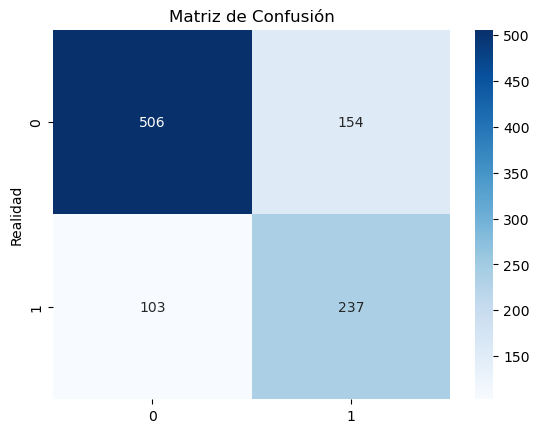

In [312]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.show()

## Conclusiones de la elección del modelo

**Impacto de negocio**

AndesLink tiene dos costos críticos:
- Perder un cliente (falso negativo) → pierde ingresos recurrentes
- Intervenir innecesariamente (falso positivo) → gasta en retención de alguien que no iba a irse

La Regresión Logística tuneada priorizaba el recall (0.76) a costa de la precisión (0.56),
detectando más churners pero generando muchas intervenciones innecesarias.

El ajuste fino logra un mejor balance: con un recall de 0.70 y una precisión de 0.61,
el modelo sigue detectando la mayoría de los clientes en riesgo, pero reduce las falsas
alarmas. Esto se traduce en campañas de retención más eficientes y un menor costo operativo
para AndesLink.